In [25]:
import pandas as pd 
import json

case_data = 'data/CasE-mutated-peptides.csv'
mhc_data = 'data/MHC-protein-sequences.json'
df_case = pd.read_csv(case_data)
with open(mhc_data, 'r') as f:
    mhc_data = json.load(f)


In [29]:
mhc_data["HLA-B*07:02"]["Protein sequence"][24:298]

'GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREEPRAPWIEQEGPEYWDRNTQIYKAQAQTDRESLRNLRGYYNQSEAGSHTLQSMYGCDVGPDGRLLRGHDQYAYDGKDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQRRAYLEGECVEWLRRYLENGKDKLERADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRTFQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW'

In [17]:
df_case.tail(3)

,Peptide ID,Peptide,HLA restriction,Peptide Length,anchor position,aaWT,residue number,aaMUT
104,CasE_55_PΩV1,NGKIQTVCH,B*08:01,9,PΩ,F,163,H
105,CasE_55_PΩV2,NGKIQTVCN,B*08:01,9,PΩ,F,163,N
106,CasE_55_PΩV3,NGKIQTVCW,B*08:01,9,PΩ,F,163,W


In [3]:
import os 

"""
data/
└── input/
    └── af/
        ├── CasE_55_PΩV1/
        │   ├── wt.json
        │   └── mut.json
        └── CasE_55_PΩV2/
            ├── wt.json
            └── mut.json

{
    "name": "MHC-A01:01_CasE-B07:02_b2mgbl",
    "modelSeeds": [1],
    "dialect": "alphafold3",
    "version": 1,
    "sequences": [
        {"protein": {"id": ["A"], "sequence": ""}},
        {"protein": {"id": ["B"], "sequence": ""}},
        {"protein": {"id": ["C"], "sequence": ""}}
    ]
}
"""
# print(mhc_data['HLA-A*01:01']['Protein sequence'][24:308])
af_input = 'data/input/af'
os.makedirs(af_input, exist_ok=True)
b2m_seq = mhc_data['Beta-2-microglobulin']['Protein sequence main (21-119)']
for i in range(len(df_case)):
    Peptide_ID,	Peptide, HLA_restriction, Peptide_Length, anchor_position, aaWT, residue_number, aaMUT = df_case.iloc[i]
    hla_key = [k for k in mhc_data.keys() if HLA_restriction in k]
    print(hla_key)
    if not hla_key:
        print(HLA_restriction)
    else:
        hla_key = hla_key[0]

    segment = mhc_data[hla_key]['UniProt']['location']['Extracellular']
    start, end = map(int, segment.split("-"))
    hla_seq = mhc_data[hla_key]['Protein sequence']
    hla_seq_extracellular = hla_seq[start-1:end]

    try: 
        int_anchor_pos = int(anchor_position[-1])
    except:
        int_anchor_pos = Peptide_Length
    WT_Peptide = Peptide[:int_anchor_pos-1] + aaWT + Peptide[int_anchor_pos:]

    wt_dict = {
        "name": "wt", 
        "modelSeeds": [1], 
        "dialect": "alphafold3", 
        "version": 1,
        "sequences": [
            {"protein": {"id": ["A"], "sequence": hla_seq_extracellular}}, # MHC
            {"protein": {"id": ["B"], "sequence": WT_Peptide}}, # Peptide
            {"protein": {"id": ["C"], "sequence": b2m_seq}} # Beta-2-microglobulin (B2M)
        ],
    }
    mut_dict = {
        "name": "mut", 
        "modelSeeds": [1], 
        "dialect": "alphafold3", 
        "version": 1,
        "sequences": [
            {"protein": {"id": ["A"], "sequence": hla_seq_extracellular}},
            {"protein": {"id": ["B"], "sequence": Peptide}},
            {"protein": {"id": ["C"], "sequence": b2m_seq}}
        ],
    }
    os.makedirs(f'{af_input}/{Peptide_ID}', exist_ok=True)

    with open(f'{af_input}/{Peptide_ID}/wt.json', 'w') as f:
        json.dump(wt_dict, f, indent=2)
    with open(f'{af_input}/{Peptide_ID}/mut.json', 'w') as f:
        json.dump(mut_dict, f, indent=2)
    print(f'{af_input}/{Peptide_ID}/wt.json')
    print(f'{af_input}/{Peptide_ID}/mut.json')
    if i == 4:
        break

['HLA-B*07:02']
data/input/af/CasE_14_P2V1/wt.json
data/input/af/CasE_14_P2V1/mut.json
['HLA-B*07:02']
data/input/af/CasE_14_P2V2/wt.json
data/input/af/CasE_14_P2V2/mut.json
['HLA-B*07:02']
data/input/af/CasE_14_P2V3/wt.json
data/input/af/CasE_14_P2V3/mut.json
['HLA-B*07:02']
data/input/af/CasE_14_P2V4/wt.json
data/input/af/CasE_14_P2V4/mut.json
['HLA-B*07:02']
data/input/af/CasE_14_P2V5/wt.json
data/input/af/CasE_14_P2V5/mut.json


(0.0, 4.5)

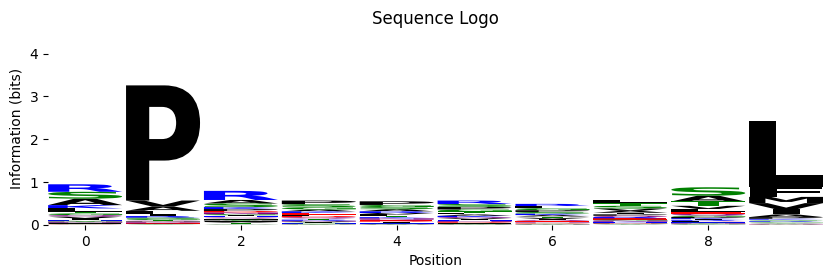

In [ ]:
import logomaker
import pandas as pd 

df = pd.read_csv("/mnt/nas_1/YangLab/loci/casE/data/data_classI_all_peptides.txt", sep='\t')

l = df[df["Allele"] == "B0702"]["Peptide"].tolist()
l = [i for i in l if len(i) == 10]

# Convert to frequency matrix
counts = logomaker.alignment_to_matrix(l)

# Convert to information matrix
info_matrix = logomaker.transform_matrix(counts, from_type='counts', to_type='information')
logo = logomaker.Logo(info_matrix)
logo.style_spines(visible=False)
logo.ax.set_ylabel("Bits")
logo.ax.set_ylim(0, 4.5)
logo.style_glyphs(color_scheme='chemistry')

logo.ax.set_xlabel("Position")
logo.ax.set_ylabel("Information (bits)")
logo.ax.set_title("Sequence Logo")

logo.ax.set_ylim(0, 4.5)
# black for hydrophobic (A,F,I,L,M,P,V,W), green for polar (C,G,N,Q,S,T,Y), blue for positively charged (H,K,R), red for negatively charged (D,E)

In [18]:
l = df[df["Allele"] == "B0702"]["Peptide"].tolist()

# l = [i for i in l if len(l) == 9]
[i for i in l if len(i) == 10]


['SPSPGIRSIM',
 'SPSPFTHTHL',
 'SPSPERSLLL',
 'SPSLRKRLQL',
 'SPSERPRQKL',
 'SPNSAHAVSL',
 'SPNELLRMEL',
 'SPMPQERGFM',
 'SPLRREKLAL',
 'SPMGTRSTLL',
 'SPLSSKRKAL',
 'SPSPSSRVTV',
 'SPLPSRTGSL',
 'SPITGEKIPA',
 'SPIRREKLAL',
 'SPGAGRNSVL',
 'SPMNKSPSAM',
 'SPSPSVREQL',
 'TIASQRLTPL',
 'SPTGGRMSVF',
 'VPAAASKISM',
 'VNVPKTRRTF',
 'VAYWRQAGLS',
 'TPYGGQFERM',
 'TPYEGQRSYL',
 'TPSPVRLHAL',
 'TPSPARSTHL',
 'TPSKPTSESF',
 'TPSGHIKRPM',
 'TPMSSHGRVL',
 'TPMDSTGVPH',
 'TPDPTVREAL',
 'TPAQPQRRSL',
 'TPAPSRTASF',
 'TPAERGRSSL',
 'SPFGKDVRLV',
 'SPTSAHLLQL',
 'SPTEKSVQAL',
 'SPEGPSKPSL',
 'SPDGNRFATA',
 'SPDSQVKEAL',
 'RPTVARISSV',
 'RPTDKPHASL',
 'RPSVRNGQLL',
 'RPSTRIQQQL',
 'RPSQNNTIGL',
 'RPSLNIATVL',
 'RPSLLLRRSL',
 'RPSGSWNGAL',
 'RPSGLRLGTP',
 'RPSGKGIVEF',
 'RPSETHADYL',
 'RPSDIKFKPL',
 'RPQSSRPVLL',
 'RPQSGRVLSA',
 'RPQPQPRPAL',
 'RPQKPQEHGL',
 'RPQGLSFLGL',
 'RPVLPSSESF',
 'SPDTAIRSGL',
 'RPVSRGGVGL',
 'RPYSPSQYAL',
 'SPDGSKILAT',
 'VPIKGTRSSL',
 'SPDGLGRLNV',
 'SPDFTLRNTL',
 'SPAPVPLP

In [1]:
import prody

/home/yang_loci/miniconda3/envs/tandem/lib/python3.11/site-packages/prody/utilities/misctools.py:424: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
p = prody.parsePDB("/mnt/nas_1/YangLab/loci/casE/data/output/control/negative/HLA-B-EDEDEDEDE/HLA-B-EDEDEDEDE_model.pdb")

@> 3154 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [4]:
glu9 = p.select("protein and chain C and resid 9")
glu9

<Selection: 'protein and chain C and resid 9' from HLA-B-EDEDEDEDE_model (10 atoms)>

In [5]:
glu9.getResnames()

array(['GLU', 'GLU', 'GLU', 'GLU', 'GLU', 'GLU', 'GLU', 'GLU', 'GLU',
       'GLU'], dtype='<U6')

In [12]:
neibors = p.select("protein and chain A within 5 of (protein and chain C and resid 9)")


In [16]:
pairs = sorted(set(zip(
    neibors.getChids(),
    neibors.getResnums(),
    neibors.getResnames()
)))

for chain, resid, resname in pairs:
    print(chain, resid, resname)


A 74 ASP
A 77 SER
A 80 ASN
A 81 LEU
A 84 TYR
A 95 LEU
A 116 TYR
A 123 TYR
A 142 ILE
A 143 THR
A 146 LYS
A 147 TRP


In [ ]:
def readRMSD(path):
    frames = []
    values = []

    with path.open() as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            if line.startswith("#"):
                continue

            frame_str, value_str = line.split()[:2]
            frames.append(int(frame_str))
            values.append(float(value_str))

    if not frames:
        raise ValueError(f"No data rows found in {path}")

    return frames, values



In [26]:
500000*0.002

1000.0

In [3]:
#!/usr/bin/env python3
"""Parse result_mmgbsa.dat into a compact JSON summary."""

import json
import re

# parser = argparse.ArgumentParser(description="Parse MMPBSA.py result_mmgbsa.dat to JSON.")
# parser.add_argument("-i", "--input", required=True, help="Input result_mmgbsa.dat file.")
# parser.add_argument("-o", "--output", help="Output JSON file. Default: input path with .json suffix.")
# args = parser.parse_args()



inputfile = "/mnt/nas_1/YangLab/loci/casE/data/output/control/negative/HLA-B-16072718/md/mmgbsa/result_mmgbsa.dat"
outputfile = "/mnt/nas_1/YangLab/loci/casE/data/output/control/negative/HLA-B-16072718/md/mmgbsa/result_mmgbsa.json"

with open(inputfile, "r") as f:
    text = f.read()

data = {
    "metadata": {},
    "sections": {
        "Complex": {},
        "Receptor": {},
        "Ligand": {},
        "Differences": {},
    },
}

metadata_patterns = {
    "run_date": r"\|\s*Run on\s+(.+)$",
    "mmpbsa_version": r"\|MMPBSA\.py Version=(.+)$",
    "solvated_complex_topology": r"\|Solvated complex topology file:\s+(.+)$",
    "complex_topology": r"\|Complex topology file:\s+(.+)$",
    "receptor_topology": r"\|Receptor topology file:\s+(.+)$",
    "ligand_topology": r"\|Ligand topology file:\s+(.+)$",
    "trajectory": r"\|Initial mdcrd\(s\):\s+(.+)$",
    "receptor_mask": r'\|Receptor mask:\s+"(.+)"$',
    "ligand_mask": r'\|Ligand mask:\s+"(.+)"$',
    "n_complex_frames": r"\|Calculations performed using\s+(.+?)\s+complex frames\.",
    "units": r"\|All units are reported in\s+(.+)\.",
}

for key, pattern in metadata_patterns.items():
    match = re.search(pattern, text, re.MULTILINE)
    if match:
        value = match.group(1).strip()
        data["metadata"][key] = float(value) if key == "n_complex_frames" else value

section = None
section_names = {"Complex:": "Complex", "Receptor:": "Receptor", "Ligand:": "Ligand"}
number_line = re.compile(
    r"^\s*([A-Za-z0-9][A-Za-z0-9\- ]*?)\s+"
    r"(-?\d+\.\d+)\s+(-?\d+\.\d+)\s+(-?\d+\.\d+)\s*$"
)

for line in text.splitlines():
    stripped = line.strip()

    if stripped in section_names:
        section = section_names[stripped]
        continue
    if stripped.startswith("Differences "):
        section = "Differences"
        continue
    if section is None:
        continue

    match = number_line.match(line)
    if not match:
        continue

    component = "_".join(match.group(1).strip().split())
    data["sections"][section][component] = {
        "average": float(match.group(2)),
        "std_dev": float(match.group(3)),
        "std_err": float(match.group(4)),
    }

with open(outputfile, "w") as f:
    f.write(json.dumps(data, indent=2) + "\n")
print(f"Wrote {outputfile}")


Wrote /mnt/nas_1/YangLab/loci/casE/data/output/control/negative/HLA-B-16072718/md/mmgbsa/result_mmgbsa.json


In [2]:
data

{'metadata': {'run_date': 'Sun May  3 19:16:48 2026',
  'mmpbsa_version': '14.0',
  'solvated_complex_topology': '/mnt/nas_1/YangLab/loci/casE/data/output/control/negative/HLA-B-16072718/md/protein_solv_ions.parm7',
  'complex_topology': '/mnt/nas_1/YangLab/loci/casE/data/output/control/negative/HLA-B-16072718/md/mmgbsa/complex.parm7',
  'receptor_topology': '/mnt/nas_1/YangLab/loci/casE/data/output/control/negative/HLA-B-16072718/md/mmgbsa/receptor.parm7',
  'ligand_topology': '/mnt/nas_1/YangLab/loci/casE/data/output/control/negative/HLA-B-16072718/md/mmgbsa/ligand.parm7',
  'trajectory': '/mnt/nas_1/YangLab/loci/casE/data/output/control/negative/HLA-B-16072718/md/mmgbsa/trajectory_wrapped.dcd',
  'receptor_mask': ':1-274,374-383',
  'ligand_mask': ':275-373',
  'n_complex_frames': 10.5,
  'units': 'kcal/mole'},
 'sections': {'Complex': {'BOND': {'average': 1262.1872,
    'std_dev': 24.6607,
    'std_err': 7.7984},
   'ANGLE': {'average': 3299.9543, 'std_dev': 22.3939, 'std_err': 7.0